# Intro

This notebook introduces the behavioral dataset and walks through how the data is cleaned before any analysis is performed. Here, the focus is on the subject's pushes and less so on continuous variables, such as gaze and position.

In [18]:
%matplotlib inline
import logging
import os

import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

from foraging import SEED
from foraging.plotting import bp, embeddable_to_conds
from foraging.plotting.behavior import BehaviorPlotter

from foraging.config.experiments import AngelakiPlottingConfig
from foraging.utils.autoreload import setup_auto_reload
from foraging.utils.data import display_df, make_angelaki_experiment, angelaki_exclusion_criteria

# Supress annoying warnings and filter out logs that aren't useful here
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.WARNING)

# Set up development tools
setup_auto_reload()
pd.options.mode.copy_on_write = True

# Important filepaths
EXPERIMENT_DIR = "../../data/experiments/angelaki"
ANALYSIS_DIR = "../../data/analysis"
FIGURES_DIR = "../../figures"

✅ Auto-reload extension already loaded!
✅ Auto-reload w/ 2 mode enabled! Changes to all packages will be automatically loaded.


# Table of Contents
- [Load Data](#Load-Data)
  - [Data Overview](#Data-Overview)
- [Analyze Outliers](#Analyze-Outliers)
  - [Example Blocks](#Example-Blocks)
  - [Block Initiation](#Block-Initiation)
  - [Reward](#Reward)
  - [Time](#Time)
  - [Space](#Space)
  - [HMM Policy Identification](#Hmm-Policy-Identification)
- [Clean Data](#Clean-Data)

# Load Data

The experiment data consists of multiple matfiles corresponding to the data for different subjects. Each matfile contains that subject's push, eye tracking (if available), and position (if available) data organized by blocks and sessions. Each block corresponds to a set of experiment parameters, notably the schedule of each box, the stimulus reliability kappa, and the stimulus type. A hierarchical overview of a given matfile is as follows:

+--- subject\
&nbsp;&nbsp;&nbsp;&nbsp; |___ session\
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |___ block (kappa, stimulus type, schedules)\
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |___ push times\
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |___ reward outcomes\
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |___ push times

For human data, each session is a subject. Unless otherwise noted, subjects underwent multiple sessions, one session per day, and each contain multiple blocks with different experiment parameters per block.
Refer to `docs\info.docx` for more details.

Here is a DataFrame showing a subset of the data. Refer to the docstring of `make_df` for more information about the contents of the DataFrame.

In [19]:
dataset = make_angelaki_experiment(EXPERIMENT_DIR)
plotter = BehaviorPlotter(dataset, AngelakiPlottingConfig().to_dict())
df = dataset.df
display_df(df, ["box", "push times", "reward outcomes"])

| box | push times | reward outcomes |
| --- | --- | --- |
| slow | 3.1349999997764826 | False |
| fast | 8.464999999850988 | False |
| fast | 9.467999999877065 | False |
| fast | 11.666999999899417 | False |
| medium | 17.125 | False |

## Data Overview
A quick overview of the summary statistics:

In [20]:
print("schedules experienced by each subject")
print(df.groupby("subject")["schedule"].unique())

schedules experienced by each subject
subject
dylan                                  [35.0, 15.0, 21.0]
humans                                  [14.0, 21.0, 7.0]
marco                            [35.0, 15.0, 21.0, 30.0]
viktor    [15.0, 21.0, 35.0, 28.0, 7.0, 14.0, 20.0, 80.0]
Name: schedule, dtype: object


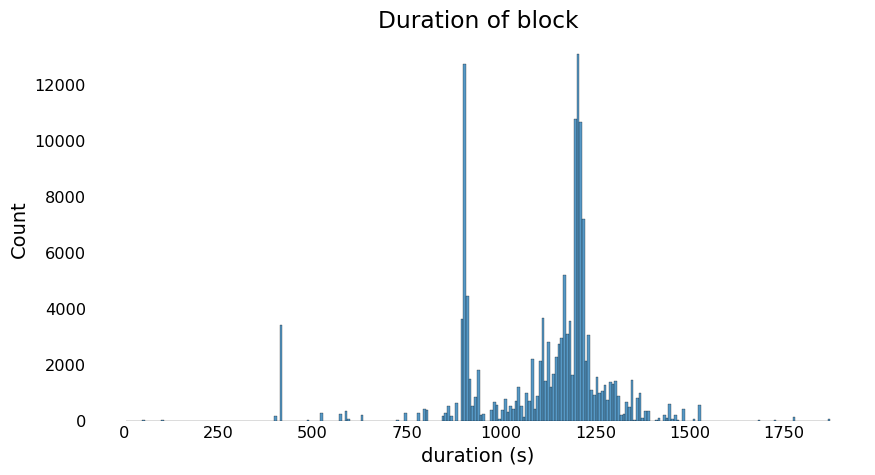

In [21]:
sns.histplot(df, x="duration")
plt.title("Duration of block")
plt.xlabel("duration (s)");

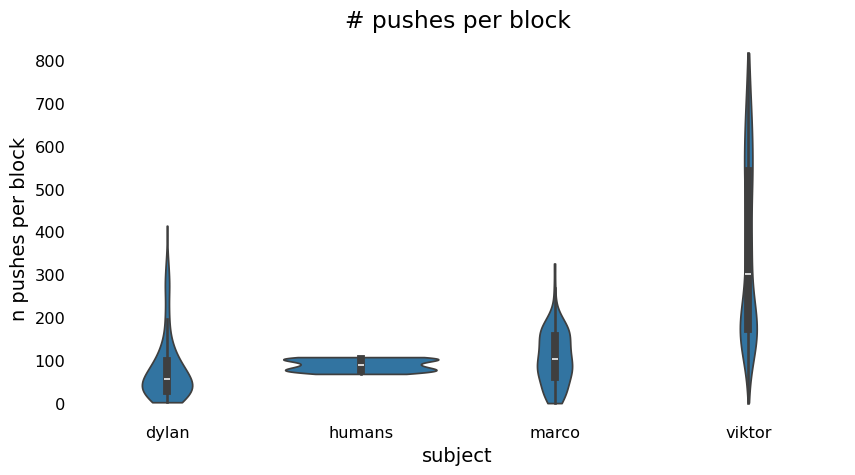

In [22]:
block_summary = (
    dataset
    .blocks
    .size()
    .reset_index(name="n pushes per block")
)
sns.violinplot(block_summary, x="subject", y="n pushes per block", cut=0)
plt.title("# pushes per block");

Here is a bird's eye view of one subject's behavioral data over the course of the entire experiment. Each row is a session of consecutive blocks. Each block's pushes are displayed as a raster plot over the duration of that block, and the pushes at each box position are stacked on top of each other (top to bottom is 3, 2, 1). Finally, pushes are colored by box schedule, so we can see how the schedules are assigned to each box over consecutive blocks.

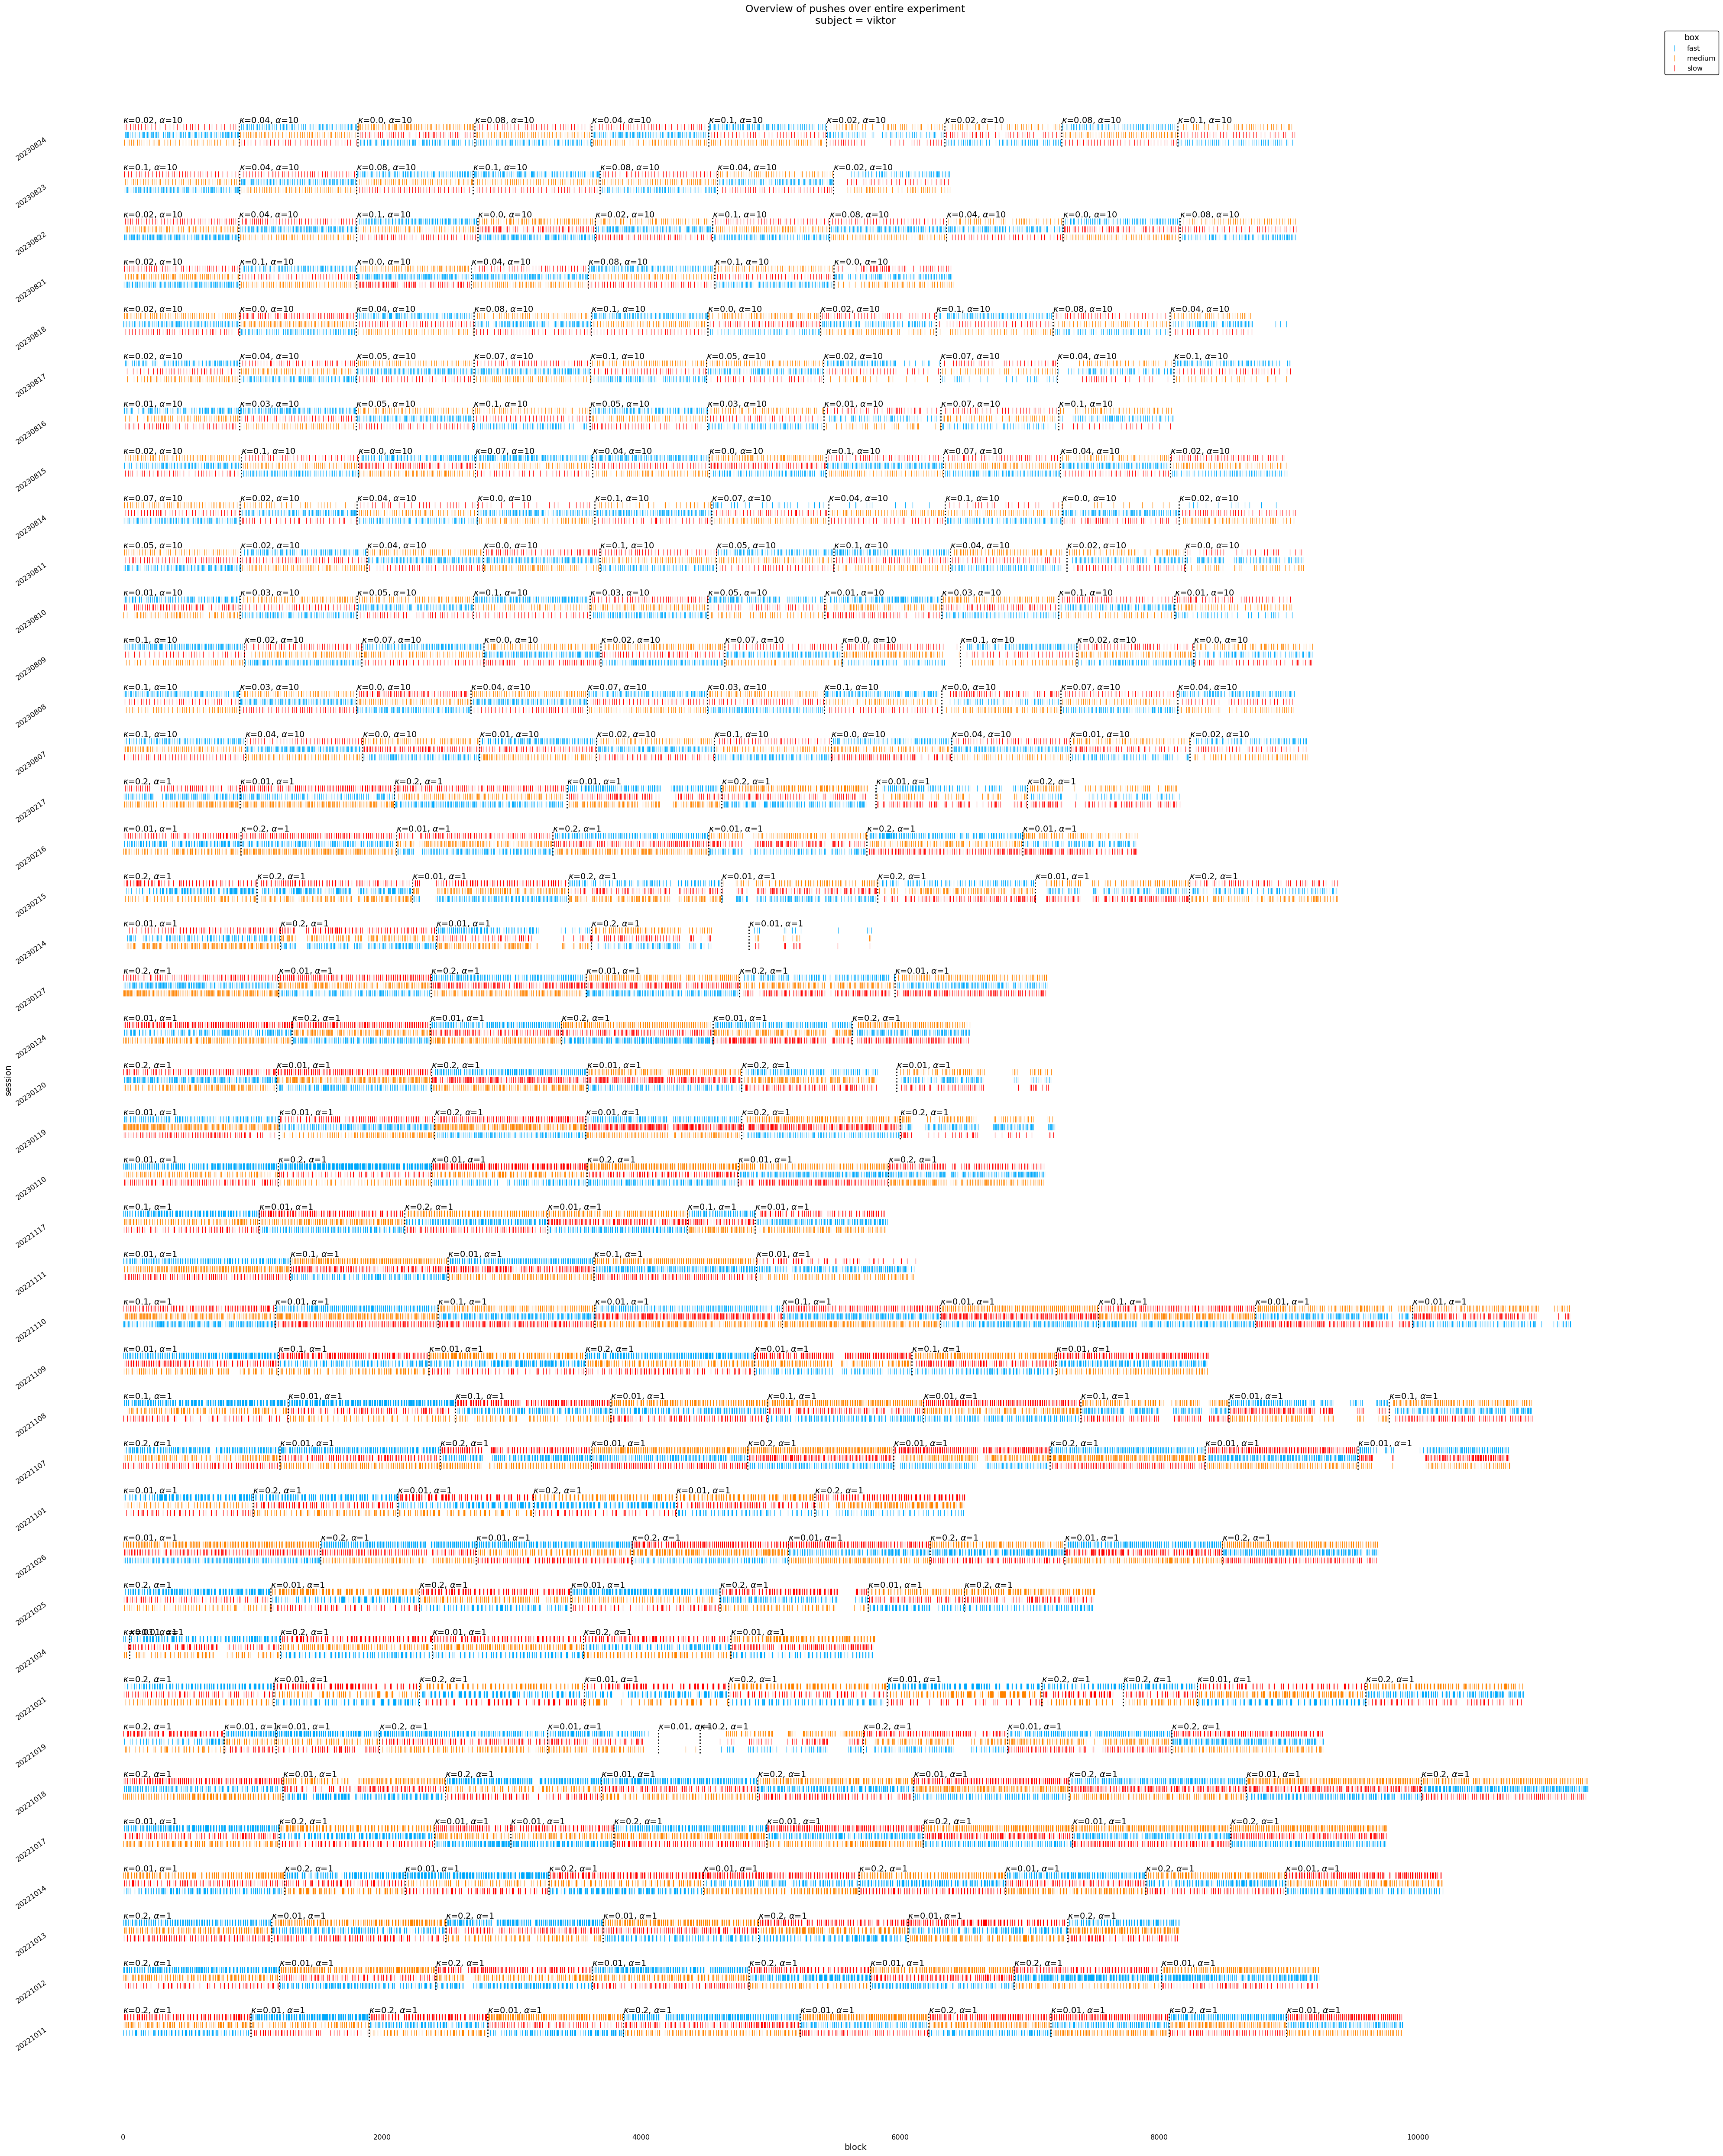

In [23]:
conds = dict(subject="viktor")
plotter.plot_experiment_overview(
    conds=conds,
    annotate_block=[r"$\kappa$", r"$\alpha$"],
    fig_kwargs=dict(figsize=(40, 50)),
);

# Analyze Outliers

Before we get to the fun stuff of analyzing behavior, it is worth taking pains to clean the data by filtering out behavior that seems "off-task". This may seem counterproductive to the goal of analyzing free behavior, but there is a trade-off between the goals of modeling as much of the behavior as possible and having a simple model of a subset of "interesting" behavior. The goal of this notebook is to design a rudimentary exclusion criteria to isolate this subset of outliers. Intuitively, long bouts of time when the subject is not pushing should be indicative of off-task or "lapse" behavior. This is a vague criterion that we will refine by exploring the distribution of consecutive push intervals, the times between consecutive pushes.

Here, each subject's consecutive push intervals are shown on a logscale, where consecutive push intervals are defined as time between consecutive pushes *irrespective of which boxes get pushed*. In later notebooks, we will make a distinction between these push intervals and push intervals between consecutive pushes *at the same box*. Henceforth, in this notebook, push intervals refer to consecutive push intervals.

The individual circles are outliers that would show up on a boxplot of the data, defined as all datapoints lying outside of 1.5*IQR (inter-quartile range) from the first and third quartile (in the original data space, not log).

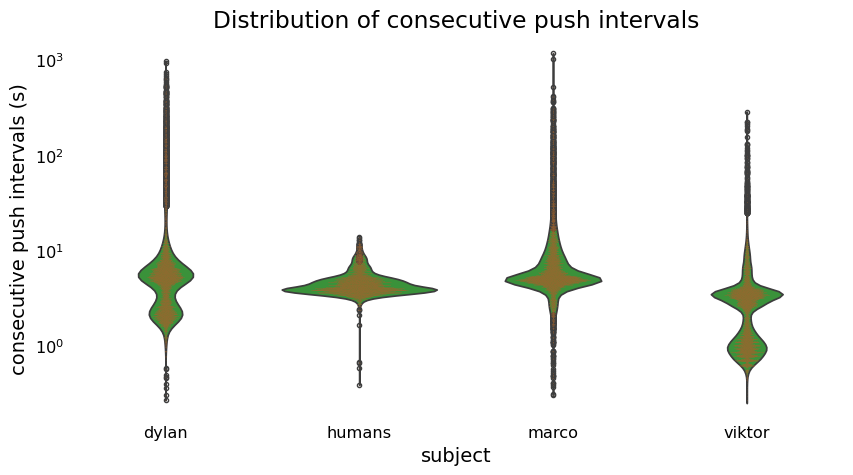

In [24]:
# Plot distribution of push intervals on log-scale
fig, ax = plt.subplots()
bp(sns.boxplot)(
    df,
    x="subject",
    y="consecutive push intervals",
    showcaps=False,
    showbox=False,
    log_scale=True,
    whiskerprops={"visible": False},
    medianprops={"visible": False},
    legend=False,
    ax=ax,
)
bp(sns.swarmplot)(
    df.groupby("subject").sample(10000, random_state=SEED, replace=True),
    x="subject",
    y="consecutive push intervals",
    legend=False,
    log_scale=True,
    size=0.25,
    dodge=True,
    ax=ax,
)
bp(sns.violinplot)(
    df,
    x="subject",
    y="consecutive push intervals",
    cut=0,
    inner=None,
    log_scale=True,
    title="Distribution of consecutive push intervals",
    y_unit="s",
    legend=False,
    ax=ax,
);

We see a mix of bimodality and unimodality among the subjects. Next, we will sort each push interval by the percentile at which it occurs in each subject's data.

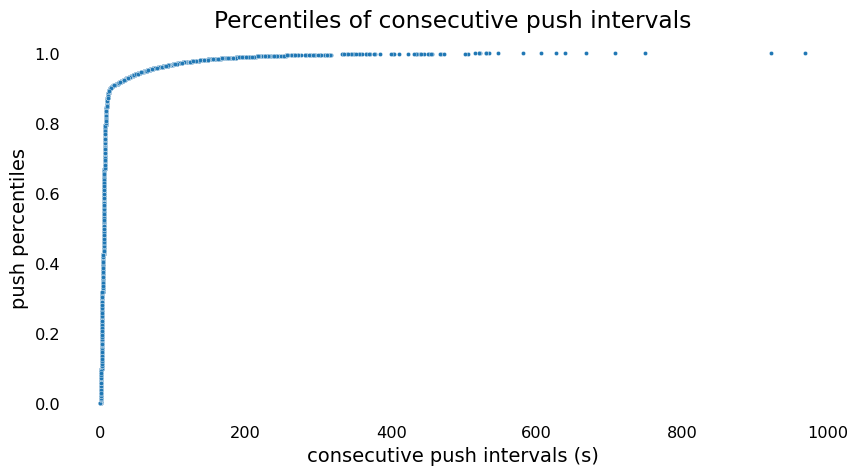

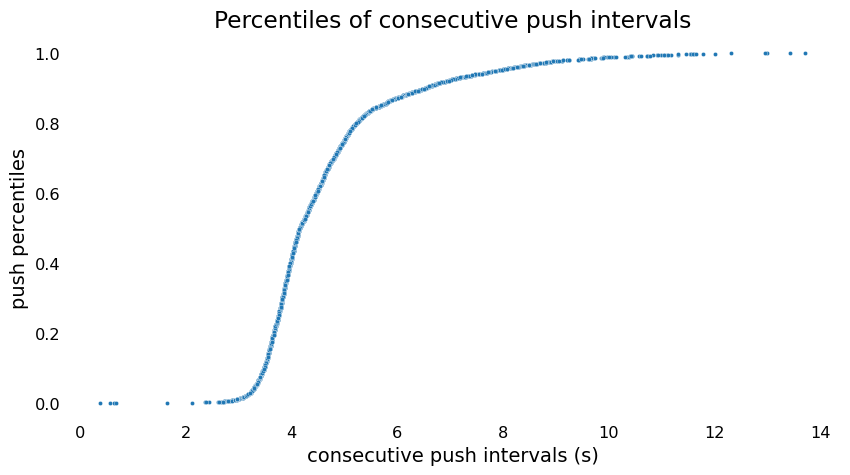

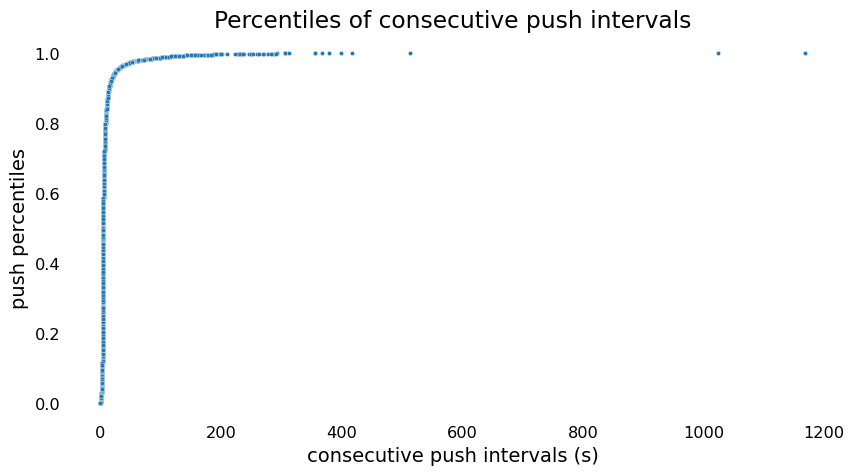

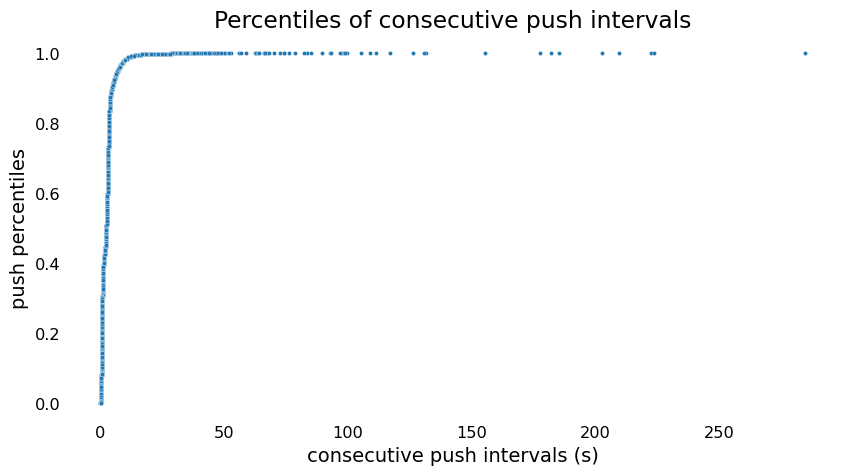

In [25]:
df["push percentiles"] = df.groupby("subject", as_index=False)[
    "consecutive push intervals"
].rank(pct=True)
plotter.plot_conditions_by_subject(plotter.plot_push_percentiles);

Aside from the humans, whose percentile curves are characteristic of a gaussian, the other subjects are heavily non-gaussian. The rest of this notebook is dedicated to getting a better sense of when a boundary emreges between normally long and abnormally long push intervals. Next, we will consider the characteristics of example blocks containing the longest push intervals.

## Example Blocks

Here are the blocks that contain the longest push intervals for each subject. Each push is labeled by its reward outcome, with filled symbols indicating reward and empty no reward, and is colored by the schedule of the box they occur at. Dashed lines connect consecutive pushes.


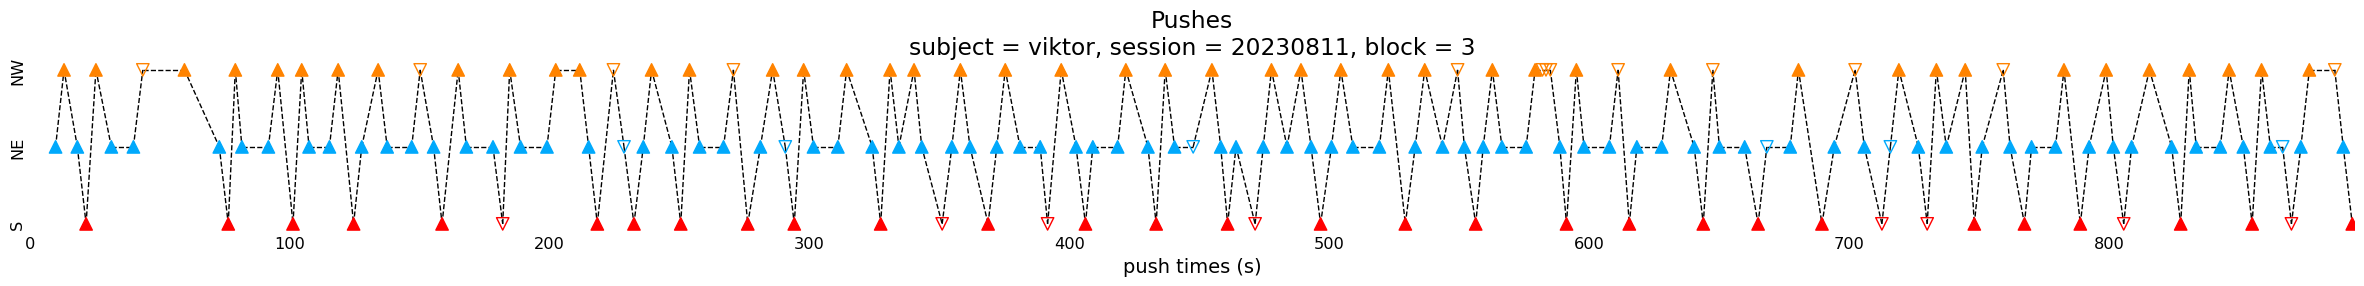

In [26]:
plotter.plot_pushes(conds = dict(subject="viktor", session=20230811, block=3), fig_kwargs=dict(figsize=(30, 2.2)), legend=False);

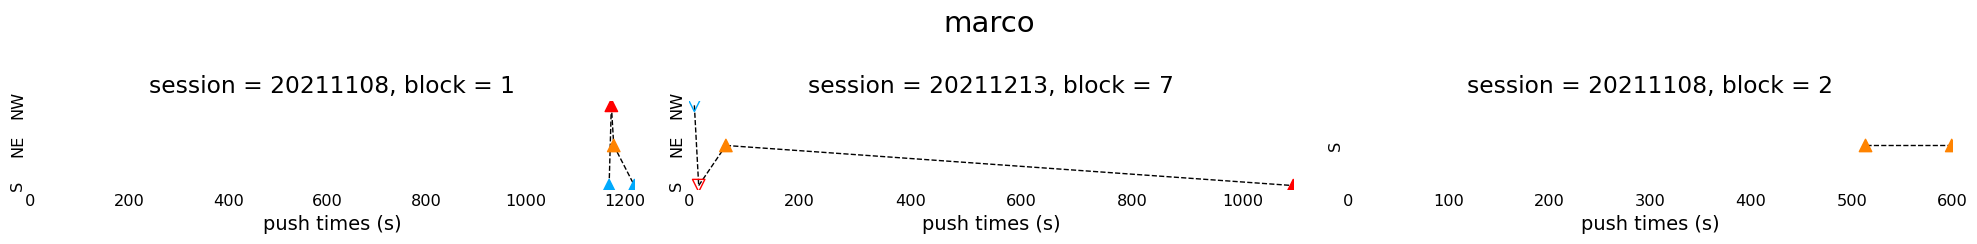

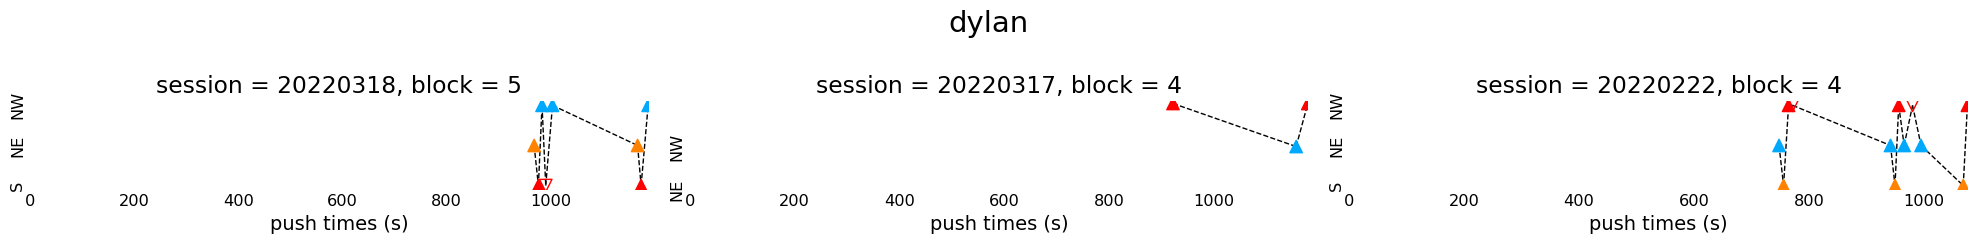

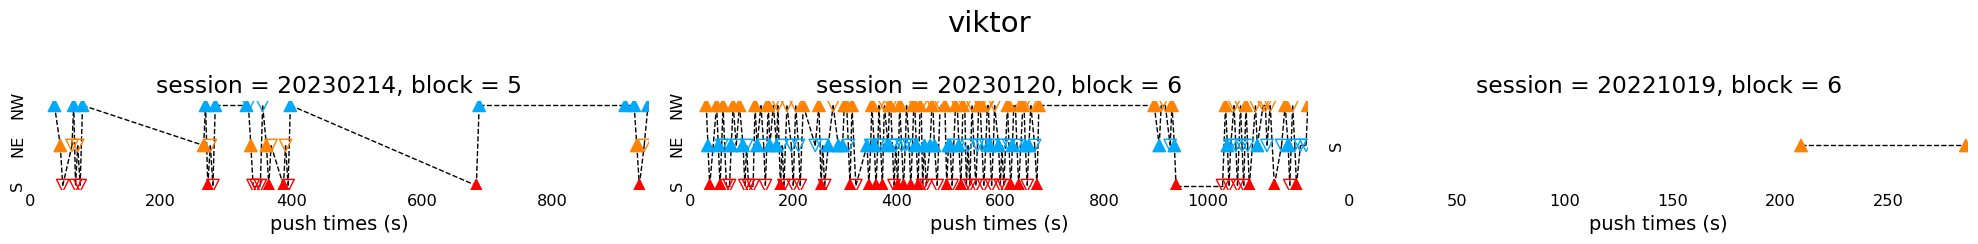

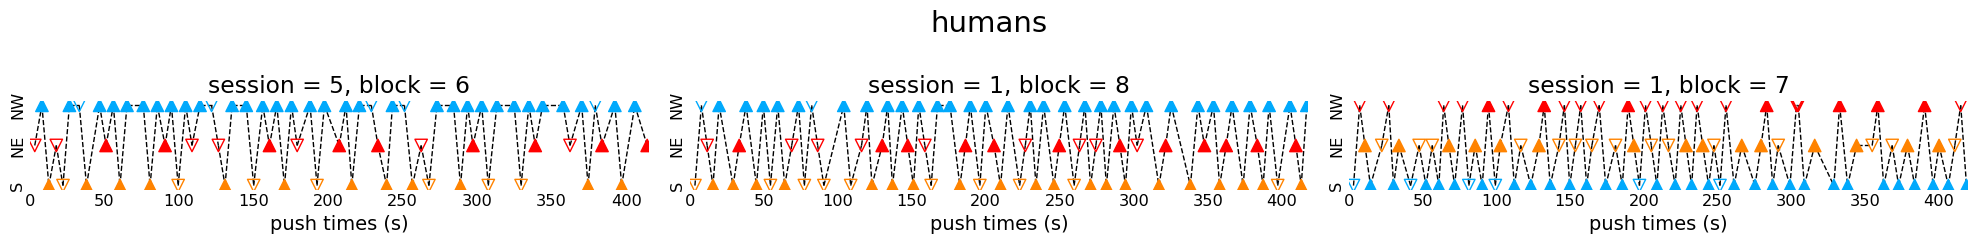

In [27]:
plotter.plot_long_push_blocks(3);

Some push intervals appear long because the subject doesn't initiate the task for a long time. We will show the distribution of initiation times next. Also, some blocks are very sparse while other blocks have long segments of task-engaged behavior interrupted by long breaks when the monkey does not push. One consideration for the exclusion criteria is to drop blocks that contain fewer than n pushes e.g. 10 pushes, even if there are a couple "reasonable looking" pushes; it's very likely the animal is actually disengaged the entirety of that block, thus casting doubt on any reasonable behavior appearing in that block. For blocks that are denser in pushes, we need a different criteria.

## Block Initiation

Here we show the distribution of times when the first push in the block occurs for each subject on logscale.



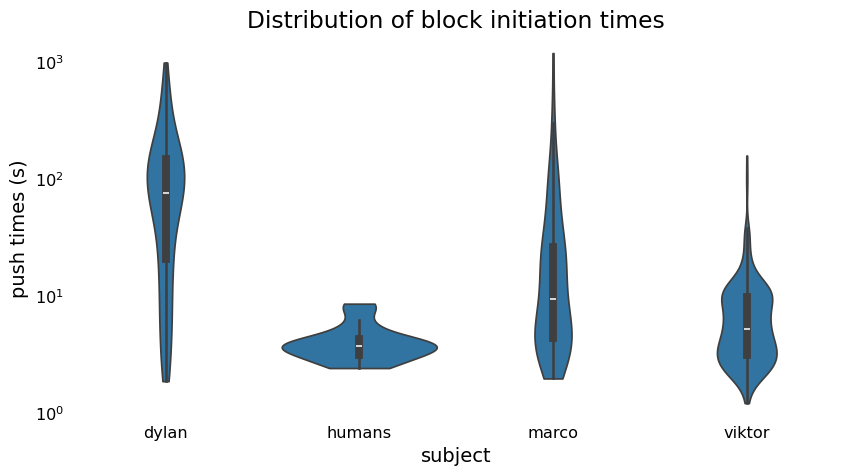

In [28]:
df_init = df.xs(1, level="push #")
bp(sns.violinplot)(
    df_init,
    x="subject",
    y="push times",
    cut=0,
    log_scale=True,
    title="Distribution of block initiation times",
    y_unit="s",
    legend=False,
);

Dylan appears to initiate the block extremely late compared to other subjects, with a mode around 100 s. Marco also seems to have a decent chunk of blocks which are initiated after 100 s. Next, we'll consider possible correlates of long push intervals, such as reward and spatial position.

## Reward

Now we will compare the relationship between reward and push intervals. For each subject, we sample 5000 pushes and count how many rewards were obtained in a 30 second window preceding each push.

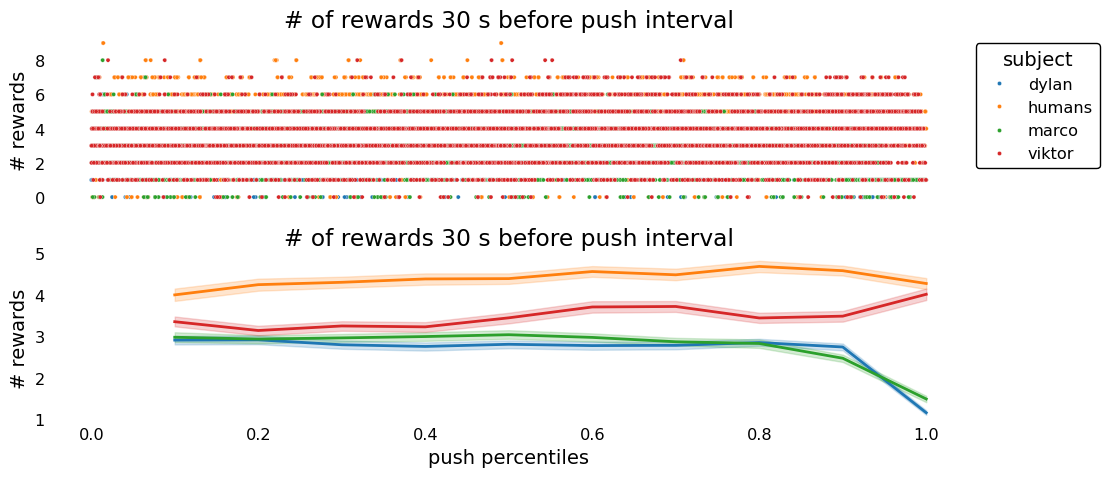

In [29]:
plotter.plot_recent_rewards_vs_push_percentiles();

It appears that for Viktor and the humans, there is a weak increase in the number of rewards preceding each push as the push interval increases. However, for Dylan and Marco, there is a sharp decline in the number of rewards for the top 20%-30% of push intervals. Could this be related to an increased failure rate or lack of pushes? This is what we look at next.

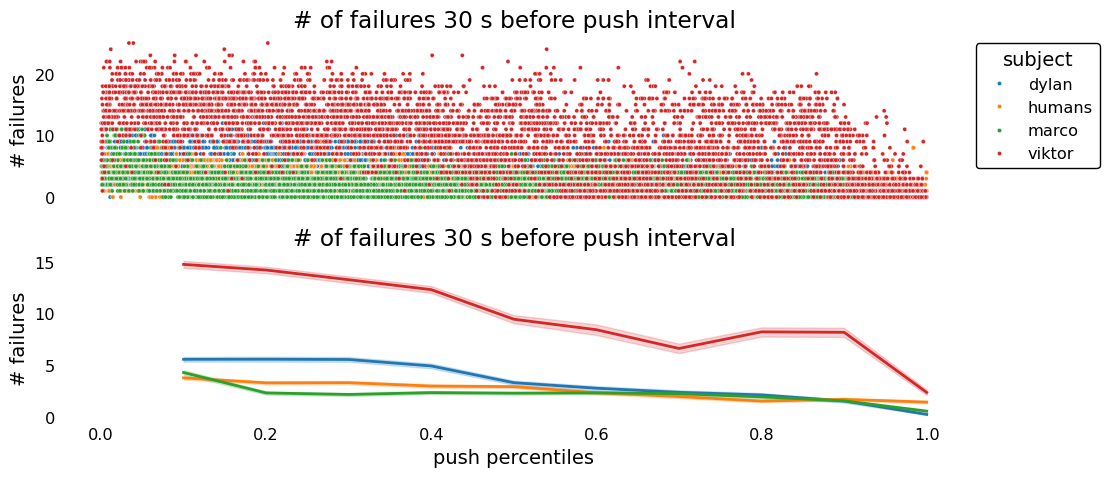

In [30]:
plotter.plot_recent_rewards_vs_push_percentiles(invert_reward=True);

So it's not the number of failures, as that goes down across all subjects to different extents. The subjects might be pushing less overall before a long push interval, suggesting that push intervals might be correlated across time. To see this, we will visualize the relationship between each push interval and the previous push interval.

## Time

Here, we plot each push interval against the previous push interval and cluster based on whether the current push is a stay push or switch push to get a sense of temporal correlations. 

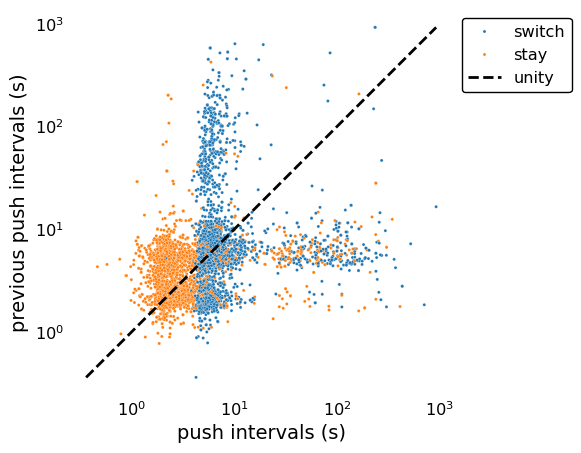

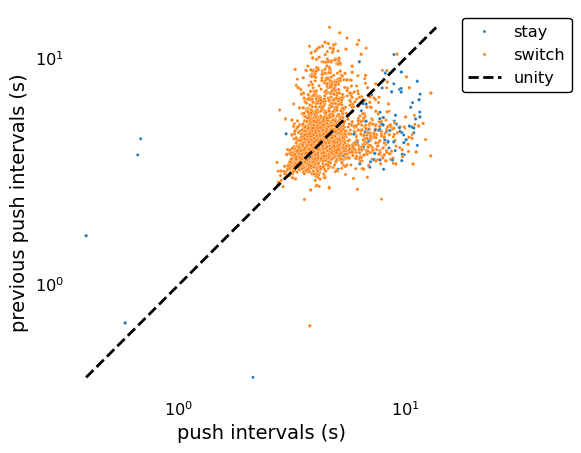

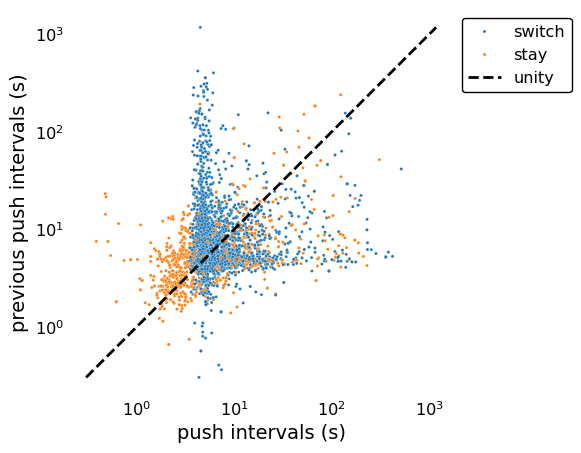

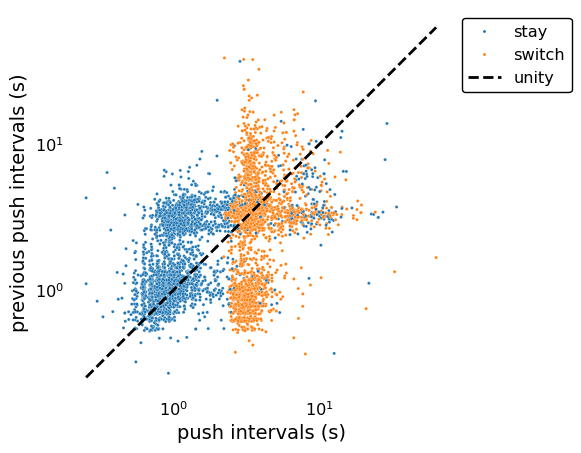

In [31]:
plotter.plot_conditions_by_subject(plotter.plot_previous_push_interval_vs_push_interval);

As expected, stay pushes are smaller push intervals than switch pushes and are preceded by similar-sized push intervals. The switch pushes have two interesting structures, a vertical and horizontal component, which represent push intervals happening independently of one another. We can also look at when each push occurs in a session to see if there are any trends such as longer pushes occurring later in the session.

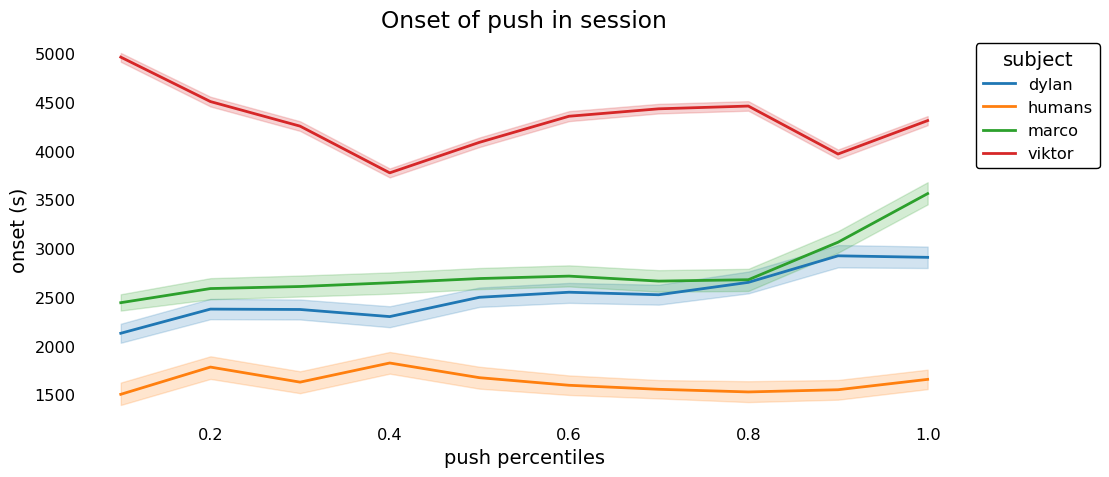

In [32]:
plotter.plot_session_onsets_vs_push_percentiles();

For Dylan and Marco, there is an increasing trend in the session onset times. For Viktor, this trend appears in the top 20% of push intervals. We can also investigate whether long push intervals tend to emerge later in each block as well.

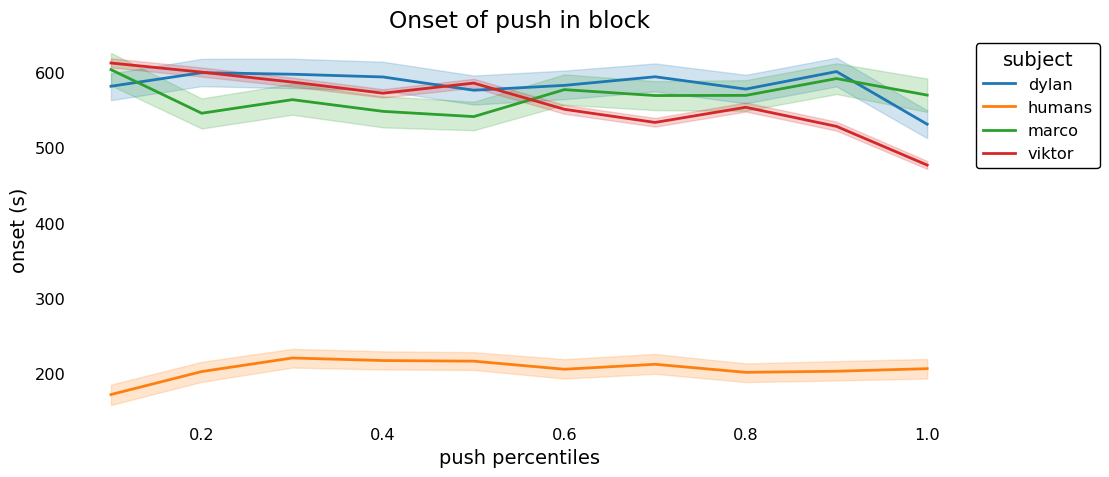

In [33]:
plotter.plot_block_onsets_vs_push_percentiles();

There doesn't really seem to be a pattern in the block onset times. Next we will look at spatial correlates of the push intervals.

## Space
Below is an example block containing a few long push intervals, and the vertical position occupied during push intervals is superimposed on top of the block.

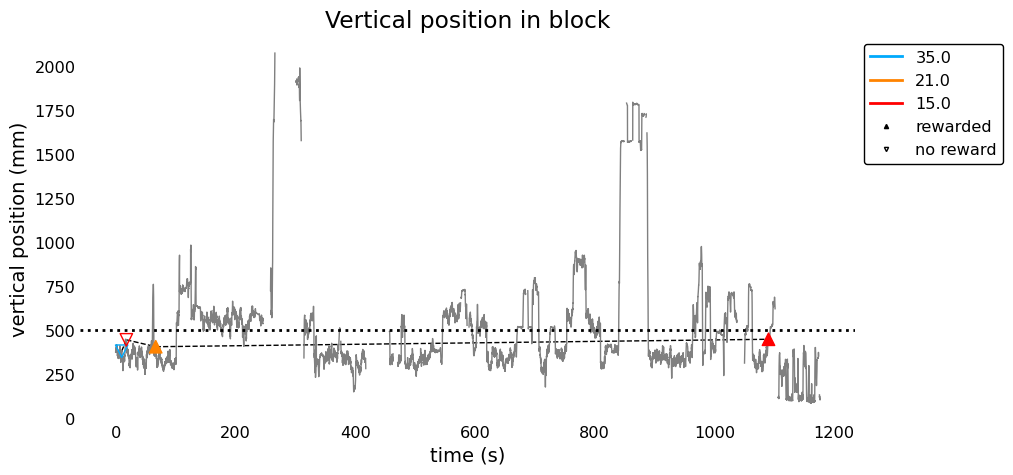

In [34]:
conds = {"subject": "marco", "session": 20211213, "block": 7}
plotter.plot_vertical_position_in_block(conds = conds, data_dir = EXPERIMENT_DIR);

This is one of the blocks that was highlighted in the `Example Block` section. There is a long push interval spanning nearly 1000 s where the subject varies between climbing and being on the ground.
We will look at the ground positions during long push intervals later. For now, we will aggregate vertical position over multiple blocks, taking the average vertical position occupied during push intervals.

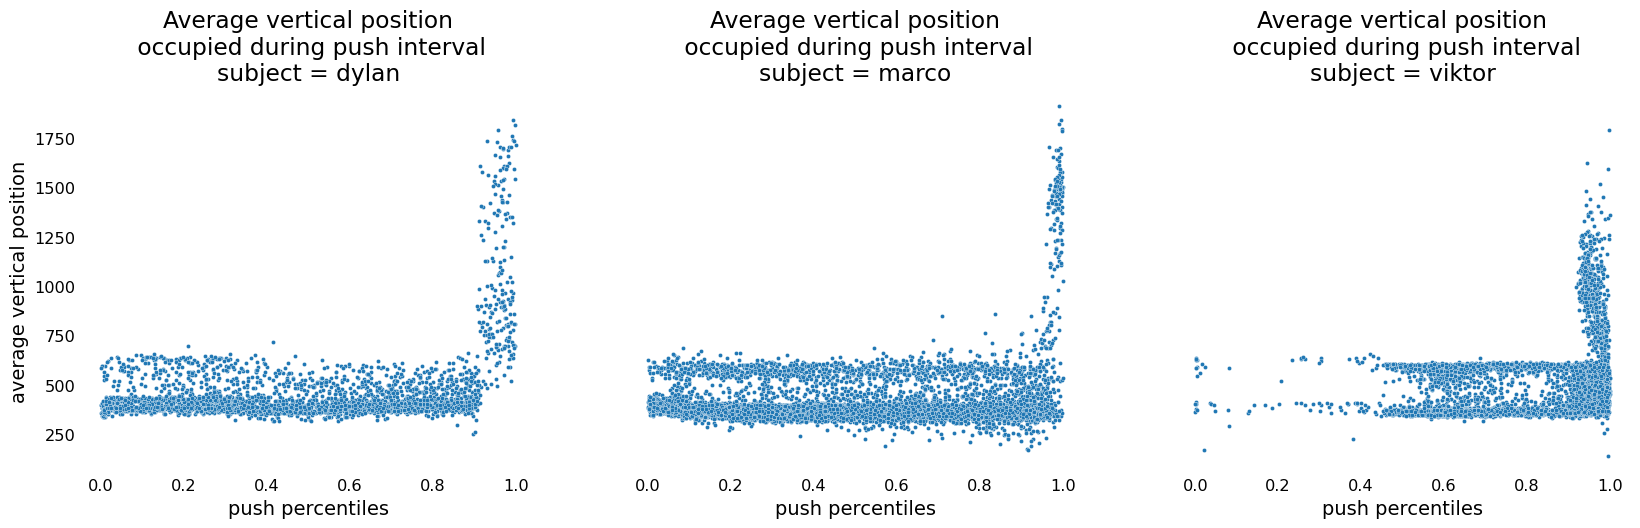

In [35]:
plotter.plot_vertical_position_vs_push_percentiles(data_dir=EXPERIMENT_DIR);

There is a very strong relationship between vertical position and the top push intervals of each subject. In particular, it looks like the top 10% of pushes is when the subjects engage in climbing.

## HMM Policy Identification

Dr. Zhe Li has been developing an automatic, data-driven way to identify patterns and clusters in the behavioral data. Fitting an HMM over a diverse set of policies, he has shared the probabilities of 2 policies over time in several blocks of Marco's behavior. Here, we overlay them on top of push intervals in a given block and observe what the HMM is picking out.


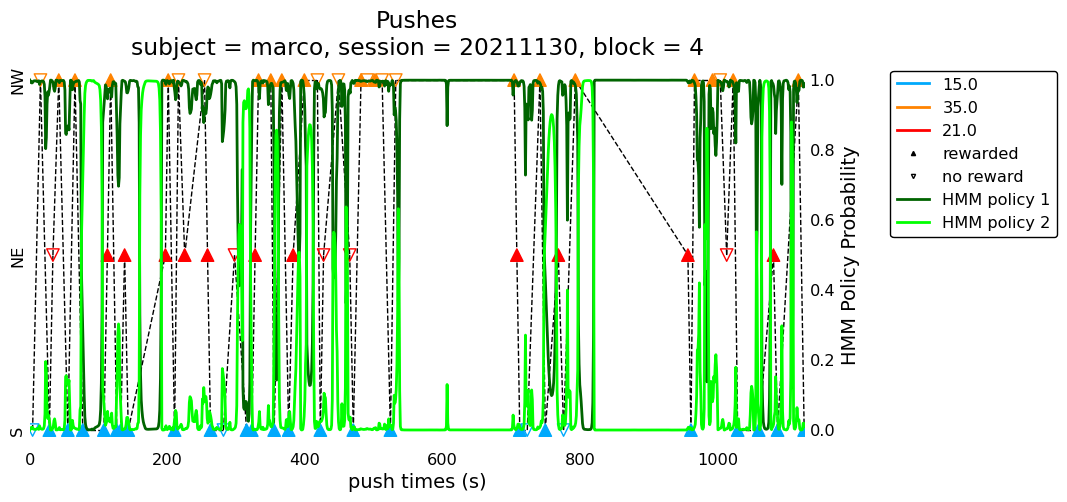

In [36]:
plotter.plot_hmm_probabilities_in_block(
    filepath = os.path.join(EXPERIMENT_DIR, "HMM.solution_[K2].pkl"), block_idx=3
);

# Clean Data

To summarize, push intervals have the following characteristics:

+ they tend to occur close together in time
+ for some subjects, the longer push intervals are preceded by an increase in reward 30 seconds before the push
+ for some subjects, longer push intervals tend to occur later in the session
+ for monkey subjects, longer push intervals are associated with the subjects' climbing around in the arena

Taking all these observations into account, the following is a preliminary exclusion criteria:

+ remove all blocks with less than 10 pushes
+ remove all blocks where the schedules contain 80 s as one of the boxes
+ remove all pushes greater than 30 s
+ remove pushes where the vertical position exceeds the height of the boxes (750 mm)

This can be greatly expanded upon and refined through automated methods that we are currently developing. For now, this is a baseline criteria that serves as a starting point for more advanced analysis.

In [37]:
%%capture --no-display
dataset_filtered = angelaki_exclusion_criteria(dataset, EXPERIMENT_DIR)

In [38]:
print(
    f"Applying exclusion criteria dropped {(len(df) - len(dataset_filtered.df))/len(df)*100:.2f}% pushes"
)

Applying exclusion criteria dropped 2.84% pushes


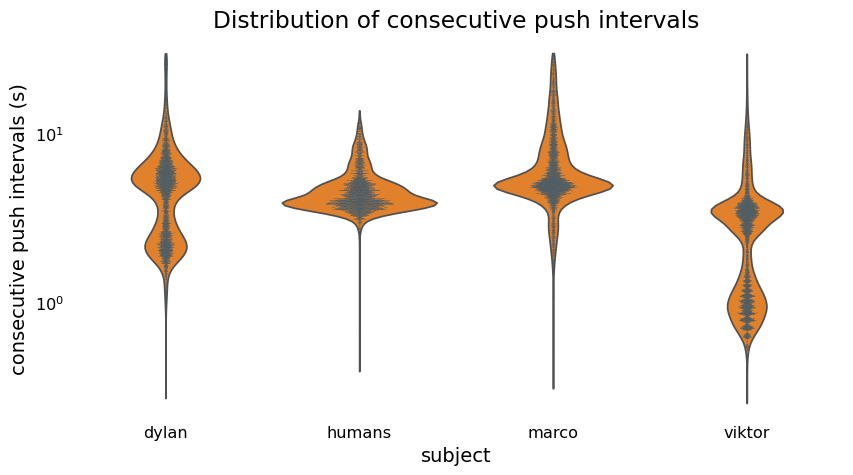

In [39]:
# Plot distribution of push intervals on log-scale
fig, ax = plt.subplots()
df_filtered = dataset_filtered.df
bp(sns.swarmplot)(
    df_filtered.groupby("subject").sample(10000, random_state=SEED, replace=True),
    x="subject",
    y="consecutive push intervals",
    legend=False,
    log_scale=True,
    size=0.25,
    dodge=True,
    ax=ax,
)
bp(sns.violinplot)(
    df_filtered,
    x="subject",
    y="consecutive push intervals",
    cut=0,
    inner=None,
    log_scale=True,
    title="Distribution of consecutive push intervals",
    y_unit="s",
    legend=False,
    ax=ax,
);

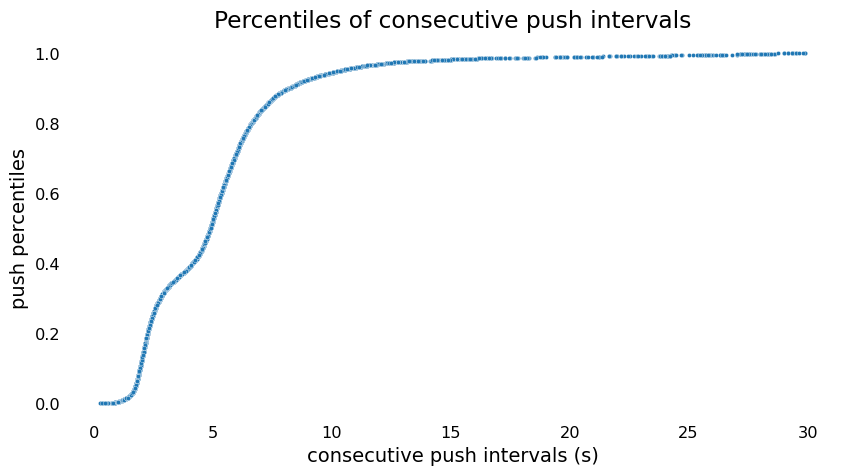

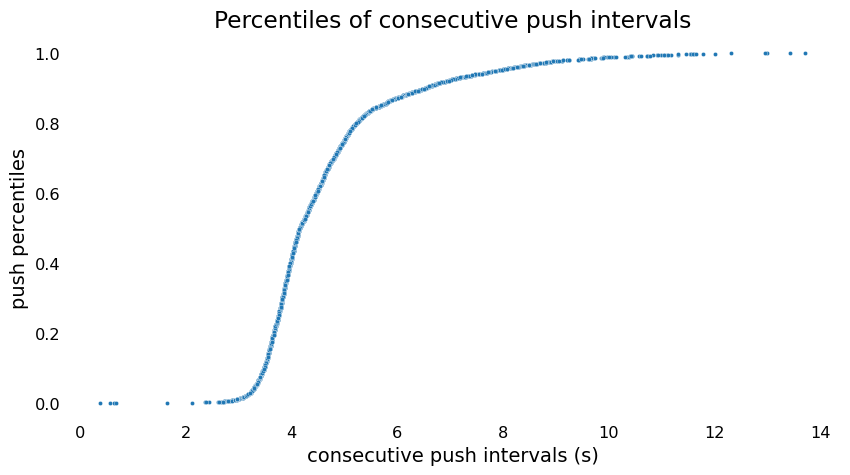

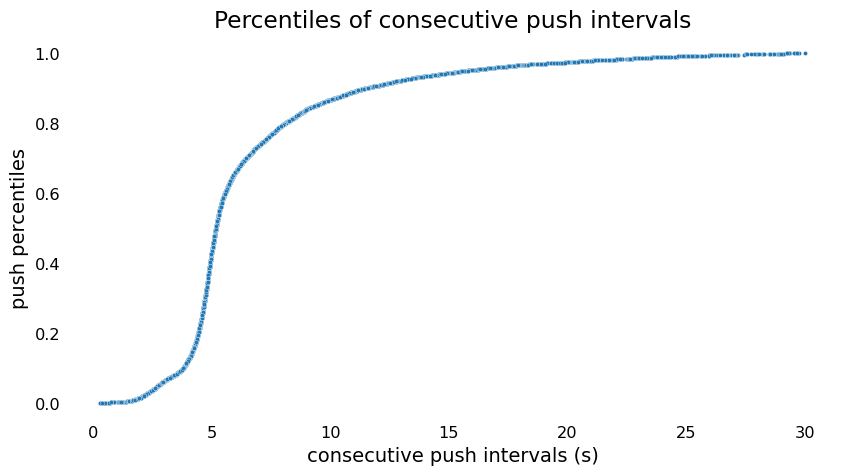

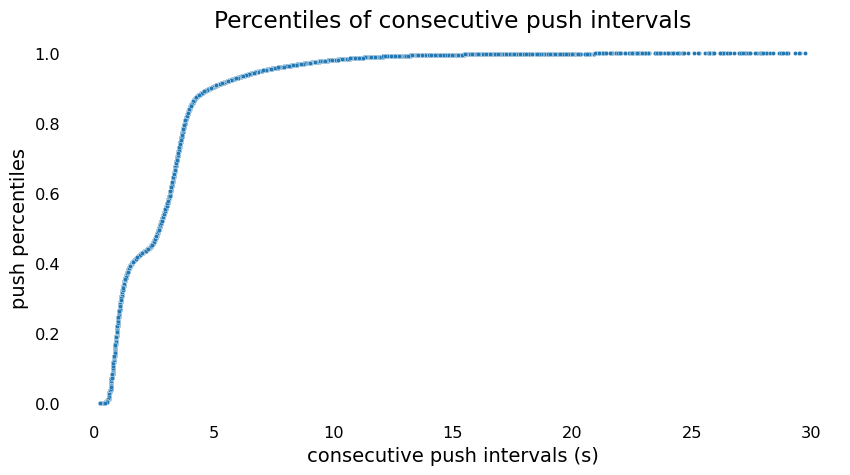

In [40]:
df_filtered["push percentiles"] = df_filtered.groupby("subject", as_index=False)[
    "consecutive push intervals"
].rank(pct=True)
plotter.dataset = dataset_filtered
plotter.plot_conditions_by_subject(plotter.plot_push_percentiles);

Compared to the beginning of this notebook, after removing the outliers for each subject, we see now that the push intervals are within a more reasonable range and behave more like a gaussian.